# Synthetic Model Generator

- define mesh & discretization
- define topography
- define earth vs air
- define density map

In [81]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from simpeg import maps
from simpeg.potential_fields import gravity
from simpeg.utils import model_builder
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)

from plots import plot_density_contrast, plot_gravity_measurements, plot_topography

### Topography Map

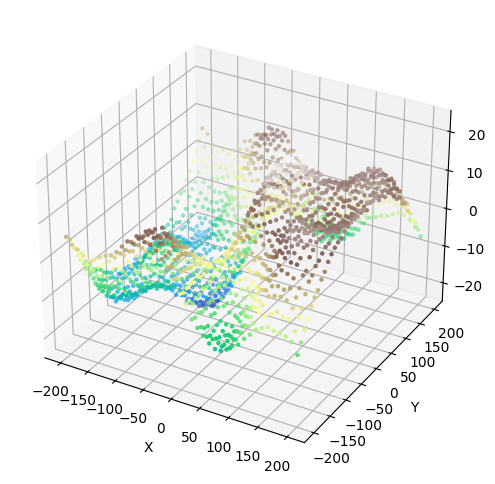

In [82]:
def synthetic_topography(
    x_min=-200, x_max=200,
    y_min=-200, y_max=200,
    dx=10, dy=10,
    base_level=0.0,
    fbm_amp=20.0,
    seed=0,
    noise_sigma=0.5,
    scatter_fraction=0.0,
):
    """
    Return (N,3) array of x,y,z points representing synthetic topography.

    Parameters
    ----------
    x_min, x_max, y_min, y_max : float
        Domain bounds.
    dx, dy : float
        Sampling grid spacing.
    base_level : float
        Base elevation (meters).
    fbm_amp : float
        Relief amplitude (meters).
    seed : int
        RNG seed.
    noise_sigma : float
        Std deviation of Gaussian noise on z.
    scatter_fraction : float
        Fraction of points randomly dropped (0–1).

    Returns
    -------
    xyz : ndarray, shape (N,3)
        Point cloud of synthetic topography.
    """
    rng = np.random.default_rng(seed)

    xs = np.arange(x_min, x_max + 1e-9, dx)
    ys = np.arange(y_min, y_max + 1e-9, dy)
    X, Y = np.meshgrid(xs, ys, indexing="xy")

    # synthetic hills from sinusoids
    Z = base_level + fbm_amp * (
        np.sin(0.01*X + seed) * np.cos(0.01*Y + seed/2)
        + 0.5*np.sin(0.03*X) * np.cos(0.02*Y)
    )

    # add noise
    Z += rng.normal(0.0, noise_sigma, size=Z.shape)

    # flatten
    XX, YY, ZZ = mkvc(X), mkvc(Y), mkvc(Z)

    # optional subsample to simulate scattered points
    if scatter_fraction > 0:
        keep = rng.random(XX.size) > scatter_fraction
        XX, YY, ZZ = XX[keep], YY[keep], ZZ[keep]

    return np.c_[XX, YY, ZZ]

# Plot
topo_xyz = synthetic_topography()
plot_topography(topo_xyz)

### Density Map

- earth vs air
- density map

In [102]:
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

# Define density contrast values for each unit in g/cc
background_density = 0.0

# Define indices of cells above & below surface (earth & air)
ind_active = active_from_xyz(mesh, topo_xyz)
nC = int(ind_active.sum())
model_map = maps.IdentityMap(nP=nC)
true_model = background_density * np.ones(nC)

def add_random_blocks(
    mesh,
    ind_active,
    base_model=None,
    n_blocks=1,
    size_frac_range=(0.05, 0.30),     # each block spans 5–30% of domain per axis
    density_range=(3, 8),     # g/cc; choose negatives for density deficit
    seed=4,
    max_tries=200,
    enforce_nonoverlap=True,
):
    """
    Returns (model, blocks_mask) where:
      - model is a copy of base_model (or zeros) with random blocks painted in
      - blocks_mask is a boolean mask (on active cells) of all block cells
    """
    rng = np.random.default_rng(seed)
    # Active cell centers (x, y, z)
    CCa = mesh.gridCC[ind_active]  # shape (n_active, 3)
    x, y, z = CCa[:, 0], CCa[:, 1], CCa[:, 2]
    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())
    z_min, z_max = float(z.min()), float(z.max())

    Lx, Ly, Lz = x_max - x_min, y_max - y_min, z_max - z_min
    # Start from provided base_model or zeros
    if base_model is None:
        model = np.zeros(ind_active.sum(), dtype=float)
    else:
        model = base_model.copy()

    # Track “occupied” cells if we want non-overlap
    occupied = np.zeros_like(model, dtype=bool)

    for k in range(n_blocks):
        placed = False
        for _ in range(max_tries):
            # Random physical sizes (axis-aligned prisms)
            fx = rng.uniform(*size_frac_range)
            fy = rng.uniform(*size_frac_range)
            fz = rng.uniform(*size_frac_range)
            sx, sy, sz = fx * Lx, fy * Ly, fz * Lz

            # Guard tiny or degenerate sizes
            if sx <= 0 or sy <= 0 or sz <= 0:
                continue

            # Random centers (keep the full block inside domain extents)
            cx = rng.uniform(x_min + sx / 2, x_max - sx / 2)
            cy = rng.uniform(y_min + sy / 2, y_max - sy / 2)
            cz = rng.uniform(z_min + sz / 2, z_max - sz / 2)

            # Axis-aligned bounds
            x0, x1 = cx - sx / 2, cx + sx / 2
            y0, y1 = cy - sy / 2, cy + sy / 2
            z0, z1 = cz - sz / 2, cz + sz / 2

            # Boolean mask on *active* cells only
            mask_k = (
                (x >= x0) & (x <= x1) &
                (y >= y0) & (y <= y1) &
                (z >= z0) & (z <= z1)
            )

            # Ensure we actually captured some cells below the surface
            if mask_k.sum() == 0:
                continue

            # Optionally avoid overlap with previous blocks
            if enforce_nonoverlap and np.any(occupied & mask_k):
                continue

            dens_k = rng.uniform(*density_range)  # g/cc
            model[mask_k] = dens_k
            occupied |= mask_k
            placed = True
            break

        if not placed:
            print(f"[warn] Block {k+1}/{n_blocks} could not be placed after {max_tries} tries.")

    return model, occupied

# ---------------------------
# Example usage with your vars
# ---------------------------
# true_model currently background; we’ll add 3 random blocks
true_model, blocks_mask = add_random_blocks(
    mesh=mesh,
    ind_active=ind_active,
    base_model=true_model,     # start from your background model
    n_blocks=1,
    size_frac_range=(0.08, 0.25),   # tweak as you like
    density_range=(3, 8),   # around your -0.2 g/cc
    seed=42,                         # remove or change for different realizations
    enforce_nonoverlap=True
)

### Plots

In [ ]:

# If you want to visualize where the blocks landed:
# import matplotlib.pyplot as plt
fig = plt.figure(figsize=(5,4)); ax = fig.add_subplot(111, projection='3d')
CCa = mesh.gridCC[ind_active]
ax.scatter(CCa[~blocks_mask,0], CCa[~blocks_mask,1], CCa[~blocks_mask,2], s=1, alpha=0.02)
ax.scatter(CCa[blocks_mask,0],   CCa[blocks_mask,1],   CCa[blocks_mask,2],   s=1)
plt.show()

plot_density_contrast(mesh, ind_active, true_model)

/tmp/ipykernel_28308/234972538.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  rgba = cm.get_cmap(cmap)(t)


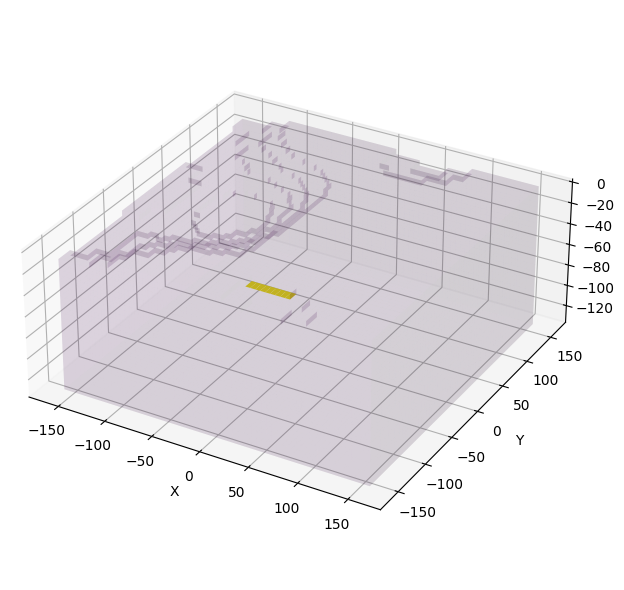

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_voxels_by_density_simple(
    mesh,
    ind_active,
    active_density,
    mode="abs",          # "abs" → use |density| for color/alpha, "raw" → use raw values
    cmap="viridis",
    alpha_min=0.05,
    alpha_max=0.95,
    edgecolor=None,
    linewidth=0.0,
    figsize=(7,6),
):
    """
    Minimal voxel renderer for SimPEG/discretize TensorMesh models.
    - Draws only active cells; opacity encodes density magnitude (or value).
    """
    # Expand active densities to full cell vector and reshape (discretize uses Fortran order)
    full = np.full(mesh.nC, np.nan)
    full[ind_active] = np.asarray(active_density, float)
    grid = full.reshape(mesh.shape_cells, order="F")

    # Build cell-edge grids once so physical sizes are correct
    x = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    filled = ~np.isnan(grid)
    vals = np.abs(np.nan_to_num(grid)) if mode == "abs" else np.nan_to_num(grid)

    if np.any(filled):
        vmin = float(np.nanmin(vals[filled]))
        vmax = float(np.nanmax(vals[filled]))
        if not np.isfinite(vmin): vmin = 0.0
        if not np.isfinite(vmax) or vmax <= vmin: vmax = vmin + 1e-9
    else:
        vmin, vmax = 0.0, 1.0

    # Normalize → color + alpha
    t = np.clip((vals - vmin) / (vmax - vmin), 0.0, 1.0)
    rgba = cm.get_cmap(cmap)(t)
    rgba[..., 3] = alpha_min + (alpha_max - alpha_min) * t
    rgba[np.isnan(grid)] = 0.0  # fully transparent for inactive cells

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    ax.voxels(X, Y, Z, filled, facecolors=rgba, edgecolor=edgecolor, linewidth=linewidth)

    ax.set_box_aspect((np.sum(mesh.h[0]), np.sum(mesh.h[1]), np.sum(mesh.h[2])))
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.tight_layout()
    plt.show()

plot_voxels_by_density_simple(
    mesh, ind_active, true_model,
    mode="abs", cmap="viridis",
    alpha_min=0.08, alpha_max=0.98,
    edgecolor=None, linewidth=0.0,
)

In [85]:
import numpy as np
import pyvista as pv

def plot_voxels_pyvista_all(
    mesh,
    ind_active,
    active_density,
    mode="abs",            # "abs" -> opacity from |density|, "raw" -> from value
    cmap="viridis",
    alpha_min=0.08,        # opacity at 0 (for zero-density cells)
    alpha_max=0.98,        # opacity at max magnitude
    background="white",
    cpos="iso",
):
    """Render all active cells with translucency ∝ |density| (no thresholding)."""
    # --- Build (nx,ny,nz) density grid (Fortran order for discretize)
    full = np.full(mesh.nC, np.nan, dtype=float)     # NaN = INACTIVE -> transparent
    full[ind_active] = np.asarray(active_density, float)
    dens_grid = full.reshape(mesh.shape_cells, order="F")

    # --- Magnitude for opacity; keep zeros as zeros (visible, low alpha)
    mag = np.abs(np.nan_to_num(dens_grid)) if mode == "abs" else np.nan_to_num(dens_grid)
    filled = ~np.isnan(dens_grid)

    # --- Normalize range
    vmax = float(np.nanmax(mag[filled])) if np.any(filled) else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    # --- Rectilinear grid from cell edges
    x_edges = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y_edges = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z_edges = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    grid = pv.RectilinearGrid(x_edges, y_edges, z_edges)
    grid.cell_data["density"] = dens_grid.ravel(order="F")

    # --- Opacity transfer function
    n_pts = 16
    opacity_tf = np.linspace(alpha_min, alpha_max, n_pts)

    # --- Plot
    p = pv.Plotter()
    p.set_background(background)

    # PyVista automatically ignores NaN cells in volume rendering
    p.add_volume(
        grid,
        scalars="density",
        cmap=cmap,
        opacity=opacity_tf,
        clim=[-vmax, vmax],      # symmetric color limits for +/- densities
        scalar_bar_args=dict(title="Density"),
    )

    p.add_axes()
    p.show_grid()
    p.camera_position = cpos
    p.show()



# --- Example usage (drop-in) ---
plot_voxels_pyvista_all(
    mesh,
    ind_active,
    true_model,
    mode="raw",            # "abs" -> opacity from |density|, "raw" -> from value
    cmap="viridis",
    alpha_min=0.001,        # opacity at 0 (for zero-density cells)
    alpha_max=0.98,        # opacity at max magnitude
    background="white",
    cpos="iso")

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


Widget(value='<iframe src="http://localhost:40237/index.html?ui=P_0x742e69451400_12&reconnect=auto" class="pyv…

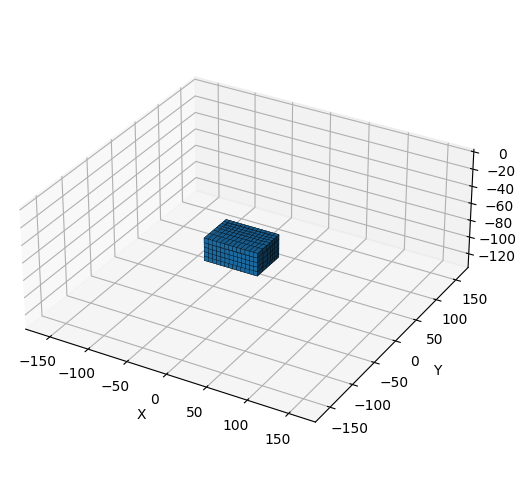

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Rebuild a full-cell boolean mask from your active subset
# ind_active: boolean array over ALL cells (len = mesh.nC) marking earth vs air
# blocks_mask: boolean array over ACTIVE cells only (len = ind_active.sum())
full_mask = np.zeros(mesh.nC, dtype=bool)
full_mask[ind_active] = blocks_mask

# 2) Reshape to (nx, ny, nz) **in Fortran order** (discretize uses 'F')
filled = full_mask.reshape(mesh.shape_cells, order="F")  # shape (nx, ny, nz)

# 3) Build the voxel corner grids so voxel sizes match your TensorMesh cell widths
x_edges = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
y_edges = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
z_edges = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
X, Y, Z = np.meshgrid(x_edges, y_edges, z_edges, indexing="ij")  # (nx+1,ny+1,nz+1)

# 4) Plot crisp voxels
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection="3d")

ax.voxels(X, Y, Z, filled, facecolors="tab:blue", edgecolor="k", linewidth=0.2)

# Make aspect ratio reflect real extents
ax.set_box_aspect((np.sum(mesh.h[0]), np.sum(mesh.h[1]), np.sum(mesh.h[2])))
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.tight_layout()
plt.show()


# 

### Survey

In [99]:
# Define the observation locations (N, 3) array
x = np.linspace(-150, 150, 20)
y = np.linspace(-150, 150, 20)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
x_topo, y_topo, z_topo = topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2]
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 5.0
receiver_locations = np.c_[x, y, z]
components = ["gz"]  # z-component of gravity (mGal), downward positive

# Weird SIMPEG library shit...
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]
source_field = gravity.sources.SourceField(receiver_list=receiver_list)
survey = gravity.survey.Survey(source_field)

### Forward Solver

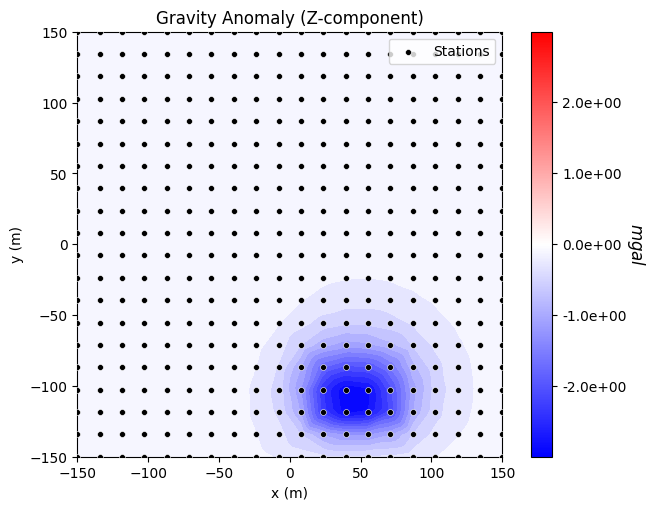

In [101]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,
    active_cells=ind_active,
    store_sensitivities="forward_only",
    engine="choclo",
)

plot_gravity_measurements(receiver_list[0].locations, simulation.dpred(true_model))